# Notebook Objectives

- Show how the value explains shifting behavior. In this notebook we already use the model-based value estimation, so the model fitting needs to be done in advance.

---
# Setup


In [1]:
# @title Imports
from tqdm import tqdm

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler


from popy.io_tools import load_behavior, load_simulation, load_behavior_yuri
from popy.plotting.plotting_tools import *
from popy.behavior_data_tools import *
from popy.config import COLORS

#from behav_analysis_tools import *

# Update the default font size
plt.rcParams.update({'font.size': 8})


In [2]:
# @title Data retrieval and loading

def get_data_custom():
    """
    Load the behavior data and preprocess it:
    - Add reaction time
    - Drop time fields
    - Add switch info (1/0 for switch/stay)
    """
    behav = load_behavior()
    behav = drop_time_fields(behav)
    behav = behav.dropna(subset=['target'])

    #behav_yuri = load_behavior_yuri()

    '''simulation_ka = load_simulation(monkey='ka')
    simulation_po = load_simulation(monkey='po')
    simulation_yu_sham = load_simulation(monkey='yu_sham')
    simulation_yu_dcz = load_simulation(monkey='yu_DCZ')
    '''
    #behav = pd.concat([behav, behav_yuri, simulation_ka, simulation_po, simulation_yu_sham, simulation_yu_dcz], ignore_index=True)

    behav = add_stay_value(behav)
    behav = add_RL_values(behav)
    behav = add_switch_info(behav, add_trials_since_switch=False)        

    #behav = add_reaction_time(behav)

    return behav

def _convert_data_to_vectors(behav):
    """
    Convert the behavior data to vectors for the model.

    X: value function of each trial, shape (n_trials, 1)
    y: switch or stay (binaty, 1/0 resp.), shape (n_trials,)
    """
    # get data - X: value function, y: switch
    X = behav.stay_value.values.reshape(-1, 1)
    #X = behav.fss_01.values.reshape(-1, 1)
    y = behav.switch.values
    y = y.astype(int)  # convert y to 0 and 1

    return X, y

def _get_probab_of_switch(X, y, x_bins):
    """
    Compute the probability of switch for each bin of the value function X.

    The probability of switch is computed as the ratio of y=1 and y=0 in the subset of x with window size of bin_size. Importantly, the classes are balanced by undersampling the majority class.
    """

    # run the model for random undersampling 1000 times, and store the probabs of switch
    probab_of_switch_full = []  # ratio of y=0 and y=1, in the subset of x with window size of bin_size
    sem_full = []  # standard error of the mean for each bin

    for i in range(1000):
        # balance classes by undersampling majority class
        X_temp, y_temp = RandomUnderSampler().fit_resample(X, y)

        probab_of_switch_temp = []  # probab of switch in target for each 

        for j in range(len(x_bins)-1):
            x_min = x_bins[j]
            x_max = x_bins[j+1]

            ids = np.argwhere((X_temp >= x_min) & (X_temp < x_max))[:, 0]
            proba_switch = np.mean(y_temp[ids]) if len(ids) > 0 else np.nan
            probab_of_switch_temp.append(proba_switch)

        probab_of_switch_full.append(probab_of_switch_temp)
    probab_of_switch_full = np.array(probab_of_switch_full)

    return np.nanmean(probab_of_switch_full, axis=0)

In [3]:
##% plotting functions
def plot_probab_of_switch(probab_of_switch_full, x_bins, ax=None, monkey=None, lw=1, show_data=False):
    """
    Plot the probability of switch as a function of the value function.
    """
    if ax is None:
        cm = 1/2.54  # centimeters in inches
        fig, ax = plt.subplots()
        fig.set_size_inches(4*cm, 3*cm)

    # first plot : probab of switch
    # plot mean
    linestyle = 'dashed' if monkey.split('_')[-1] == 'simulation' else 'solid'
    if linestyle == 'dashed':
        color = COLORS['_'.join(monkey.split('_')[:-1])]
    else:
        color = COLORS[monkey]
    alpha = .5 if monkey.split('_')[-1] == 'simulation' else 1

    # Calculate mean and error
    means = np.nanmean(probab_of_switch_full, axis=0)
    sems = np.nanstd(probab_of_switch_full, axis=0) 

    # Plot line
    ax.plot(x_bins[:-1] + (x_bins[1] - x_bins[0]) / 2,  # Shift the x_bins to the center of the bins
            means,
            linewidth=lw,
            color=color,
            linestyle=linestyle,
            label=monkey.upper() if monkey is not None else 'Mean')
    
    if show_data:
        # Plot individual data points
        for i in range(probab_of_switch_full.shape[0]):
            ax.plot(x_bins[:-1],
                    probab_of_switch_full[i, :],
                    color=color,
                    alpha=0.1)

    # Add shaded error region
    ax.fill_between(x_bins[:-1] + (x_bins[1] - x_bins[0]) / 2,
                    means - sems,
                    means + sems,
                    color=color,
                    alpha=0.2)  # Transparency level
    # plot std
    '''ax.fill_between(x_bins[:-1], 
                    np.mean(probab_of_switch_full, axis=0) - np.std(probab_of_switch_full, axis=0), 
                    np.mean(probab_of_switch_full, axis=0) + np.std(probab_of_switch_full, axis=0), 
                    color=COLORS[monkey], alpha=0.2)'''

    # plot settings
    ax.set_ylabel('Probability of switch')
    ax.set_xlabel('Value estimate')
    ax.set_ylim([-0.05, 1.05])
    ax.set_xlim([-.05, 1.05])

    # hide the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    #ax.grid(alpha=0.3)
    ax.legend(frameon=True, loc='upper right')

    return ax

def plot_roc_curve(fpr, tpr, auc, ax=None, monkey=None, lw=5):
    """
    Plot the ROC curve and the AUC.
    """
    if ax is None:
        cm = 1/2.54  # centimeters in inches
        fig, ax = plt.subplots()
        fig.set_size_inches(5*cm, 5*cm)
        # Set equal aspect ratio for the plot
        ax.set_aspect('equal', adjustable='box')

    # plot unbalance
    linestyle = 'dashed' if monkey.split('_')[-1] == 'simulation' else 'solid'
    if linestyle == 'dashed':
        color = COLORS['_'.join(monkey.split('_')[:-1])]
    else:
        color = COLORS[monkey]

    ax.plot(fpr, tpr, 
            label=f'{monkey.upper()}, AuC {auc:.2f}' if monkey is not None else 'ROC curve', 
            linewidth=lw, color=color, linestyle=linestyle)
    # fill under the curve
    ax.fill_between(fpr, tpr, color='grey', alpha=.1)

    # plot chance
    ax.plot([0, 1], [0, 1], color='grey', linestyle='dashed')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend(loc='lower right', frameon=True)

    # Adjust layout
    if ax.get_figure() is not None:
        ax.get_figure().tight_layout()

    return ax

def plot_value_vs_shift(behav, paper_format=False):
    # Main plotting loop
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h, w1, w2 = 1.75, 1.8, 1.75
        lw_1, lw_2 = 1.5, 2.3
    else:
        plt.rcParams.update({'font.size': 18})
        h, w1, w2 = 4, 6, 4
        lw_1, lw_2 = 5, 3  # line width

    # Calculate total width and width ratios to achieve desired subplot sizes
    total_width = w1 + w2
    width_ratios = [w1, w2]  # Use actual widths as ratios
    
    fig, axs = plt.subplots(1, 2, figsize=(total_width, h), 
                           gridspec_kw={'width_ratios': width_ratios, 'wspace': 0})
    
    # Ensure the second subplot is square by adjusting its aspect ratio
    axs[1].set_aspect('equal', adjustable='box')

    for monkey, behav_monkey in behav.groupby('monkey'):
        probas_per_monkey = []
        for session, behav_temp in behav_monkey.groupby('session'):
            behav_temp = behav_temp.dropna()  # drop NaN values

            # get data for probability of switch plot
            X, y = _convert_data_to_vectors(behav_temp)

            # probability of switch
            nbins = 10
            x_bins = np.linspace(0, 1.001, nbins)
            probab_of_switch_temp = _get_probab_of_switch(X, y, x_bins)

            probas_per_monkey.append(probab_of_switch_temp)

        probas_per_monkey = np.array(probas_per_monkey)

        # plot probability of switch
        plot_probab_of_switch(probas_per_monkey, x_bins, ax=axs[0], monkey=monkey, lw=lw_1, show_data=False)

    for monkey, behav_monkey in behav.groupby('monkey'):
        behav_monkey = behav_monkey.dropna()  # drop NaN values

        # get data for probability of switch plot
        X, y = _convert_data_to_vectors(behav_monkey)

        # ROC AUC
        fpr, tpr, _ = roc_curve(y, X, drop_intermediate=False, pos_label=0)
        auc = roc_auc_score(-y, X)

        plot_roc_curve(fpr, tpr, auc, ax=axs[1], monkey=monkey, lw=lw_2)
        
    # Save the figures
    if not paper_format:
        fig.tight_layout()

    return fig, axs

---
# Get data

In [4]:
behav = get_data_custom()
#behav = behav.drop(columns=['value_function'])
#behav = behav.dropna()
behav = behav.drop(columns=['stay_proba'])

---
# Section 2: Action value vs probab shift

/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_10480/2797016180.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(probab_of_switch_full, axis=0)
/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_10480/2797016180.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(probab_of_switch_full, axis=0)
/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_10480/2797016180.py:74: RuntimeWarning: Mean of empty slice
  return np.nanmean(probab_of_switch_full, axis=0)


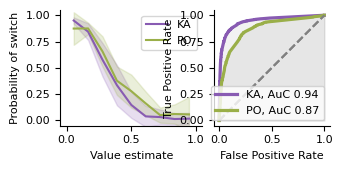

In [5]:
monkeys = ['ka', 'po']#, 'ka_simulation', 'po_simulation']

# Now when the warning occurs, it will raise an exception and stop execution
fig, axs = plot_value_vs_shift(behav.loc[behav['monkey'].isin(monkeys)], paper_format=True)

# save the figure svg
plt.savefig('figs/value_vs_shift.svg', dpi=300, bbox_inches='tight', transparent=True, format='svg')

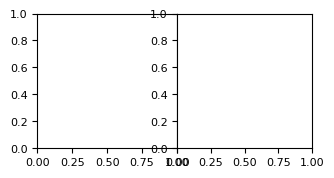

In [6]:
monkeys = ['yu_sham', 'yu_DCZ']#, 'yu_sham_simulation', 'yu_DCZ_simulation']
fig, axs = plot_value_vs_shift(behav.loc[behav['monkey'].isin(monkeys)], paper_format=True)
# remove legends


---
# Section 3: Q-values vs probab shift

In [8]:
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize

def plot_q_vals_roc(behav, paper_format=False):
    """
    Plot the ROC curve for the value function.
    """
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h, w1  = 1.75, 1.75
        lw_1, lw_2 = 1.5, 2.3
    else:
        plt.rcParams.update({'font.size': 18})
        h, w1 = 4, 4
        lw_1, lw_2 = 5, 3  # line width

    fig, ax = plt.subplots(1, 1, figsize=(w1, h))
    
    for monkey, behav_monkey in behav.groupby('monkey'):
        behav_monkey = behav_monkey.dropna()  # drop NaN values

        # get data for probability of switch plot
        y_true = behav_monkey['target']
        y_true_onehot = label_binarize(y_true, classes=[1, 2, 3])  # shape: (n_samples, 3)

        q_values = behav_monkey[['Q_1', 'Q_2', 'Q_3']].values  # shape: (n_samples, 3)

        fpr, tpr, _ = roc_curve(y_true_onehot.ravel(), q_values.ravel())
        auc_model2 = roc_auc_score(y_true_onehot, q_values, average='macro', multi_class='ovr')
        print(f"Model 2 Macro-Averaged AUC (3-way choice): {auc_model2:.3f}")

        plot_roc_curve(fpr, tpr, auc_model2, ax=ax, monkey=monkey, lw=lw_2)

    return fig, ax

Model 2 Macro-Averaged AUC (3-way choice): 0.913
Model 2 Macro-Averaged AUC (3-way choice): 0.807


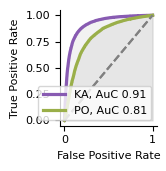

In [9]:
monkeys = ['ka', 'po']#, 'ka_simulation', 'po_simulation']

# Now when the warning occurs, it will raise an exception and stop execution
fig, ax = plot_q_vals_roc(behav.loc[behav['monkey'].isin(monkeys)], paper_format=True)

# save the figure svg
#plt.savefig('figs/value_vs_shift.svg', dpi=300, bbox_inches='tight', transparent=True, format='svg')

AttributeError: 'NoneType' object has no attribute 'remove'

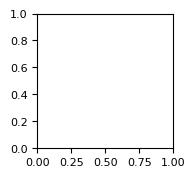

In [10]:
monkeys = ['yu_sham', 'yu_DCZ']#, 'yu_sham_simulation', 'yu_DCZ_simulation']
# Now when the warning occurs, it will raise an exception and stop execution
fig, ax = plot_q_vals_roc(behav.loc[behav['monkey'].isin(monkeys)], paper_format=True)
# remove legend
ax.legend_.remove()


Model 2 Macro-Averaged AUC (3-way choice): 0.913
Model 2 Macro-Averaged AUC (3-way choice): 0.807


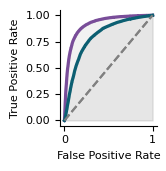

In [ ]:
monkeys = ['yu_sham', 'ka', 'po']
# Now when the warning occurs, it will raise an exception and stop execution
fig, ax = plot_q_vals_roc(behav.loc[behav['monkey'].isin(monkeys)], paper_format=True)
# remove legend
ax.legend_.remove()